# ***Carga de librerías***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

# ***Carga del dataset***

In [2]:
# Cargamos el dataset post limpieza en parquet
df = pd.read_parquet("../data/data_clean.parquet")
df.shape

(797815, 17)

## ***Primer vistazo visual***

In [3]:
# Miramos que se haya cargado bien haciendo un head()
df.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,12,0,83.4,2009,12,1,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,48,0,100.8,2009,12,1,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,24,0,30.0,2009,12,1,1,7


In [ ]:
# Comprobamos como están las variables en el describe()
df.describe()

,quantity,invoice_date,price,customer_id,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
count,797815.000000,797815,797815.000000,797815.0,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000
mean,12.585594,2011-01-02 13:15:39.345813504,3.703057,15313.15744,13.178434,-0.592839,20.418256,2010.431109,7.411384,15.387526,2.632767,12.800976
min,-80995.000000,2009-12-01 07:45:00,0.001000,12346.0,0.000000,-80995.000000,-168469.600000,2009.000000,1.000000,1.000000,0.000000,6.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.0,2.000000,0.000000,4.350000,2010.000000,5.000000,8.000000,1.000000,11.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.0,5.000000,0.000000,11.700000,2010.000000,8.000000,15.000000,2.000000,13.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16789.0,12.000000,0.000000,19.500000,2011.000000,10.000000,23.000000,4.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0,80995.000000,0.000000,168469.600000,2011.000000,12.000000,31.000000,6.000000,21.000000
std,191.163061,NaN,71.395672,1696.437628,144.179201,125.459350,313.532519,0.568895,3.424469,8.658267,1.944577,2.306712


In [ ]:
# Sacamos también la información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       797815 non-null  string        
 1   stock_code    797815 non-null  string        
 2   description   797815 non-null  string        
 3   quantity      797815 non-null  int64         
 4   invoice_date  797815 non-null  datetime64[ns]
 5   price         797815 non-null  float64       
 6   customer_id   797815 non-null  Int64         
 7   country       797815 non-null  category      
 8   is_return     797815 non-null  bool          
 9   quantity_pos  797815 non-null  int64         
 10  quantity_neg  797815 non-null  int64         
 11  total_price   797815 non-null  float64       
 12  year          797815 non-null  int32         
 13  month         797815 non-null  int32         
 14  day           797815 non-null  int32         
 15  day_of_week   797

---

# ***Visualizaciones avanzadas***

En el siguiente apartado comenzamos a sacar las visualizaciones avanzadas sobre los datos del parquet.

## ***Top 10 paises por número de transacciones***

,n_transacciones
country,
United Kingdom,716069
Germany,17331
EIRE,16012
France,13896
Netherlands,5132
Spain,3753
Belgium,3109
Switzerland,3057
Portugal,2414


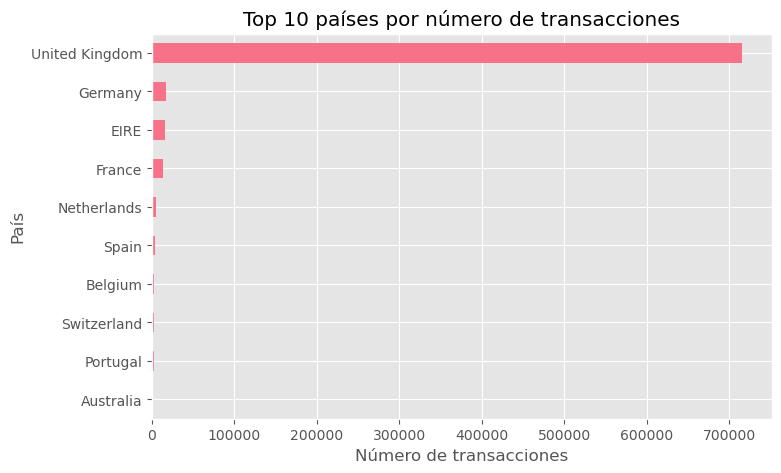

In [ ]:
# Top 10 países por número de transacciones
country_counts = df["country"].value_counts().head(10)

display(country_counts.to_frame("n_transacciones"))

ax = country_counts.sort_values().plot(
    kind="barh", figsize=(8, 5), title="Top 10 países por número de transacciones"
)
ax.set_xlabel("Número de transacciones")
ax.set_ylabel("País")
plt.show()

El dataset presenta una **altísima concentración geográfica en United Kingdom**, que domina claramente el volumen de transacciones frente al resto de países.
-   Esto indica que el negocio está fuertemente centrado en este mercado, y que los patrones observados en el análisis están principalmente influenciados por el comportamiento de los clientes de esta región.

**Implicación de negocio:**  
Cualquier estrategia o modelo desarrollado estará altamente condicionado por este mercado, por lo que su generalización a otros países puede requerir ajustes adicionales.

---

## ***Número de facturas únicas por clientes***

,compras_por_cliente
count,5939.000000
mean,7.555144
std,15.970199
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,510.000000


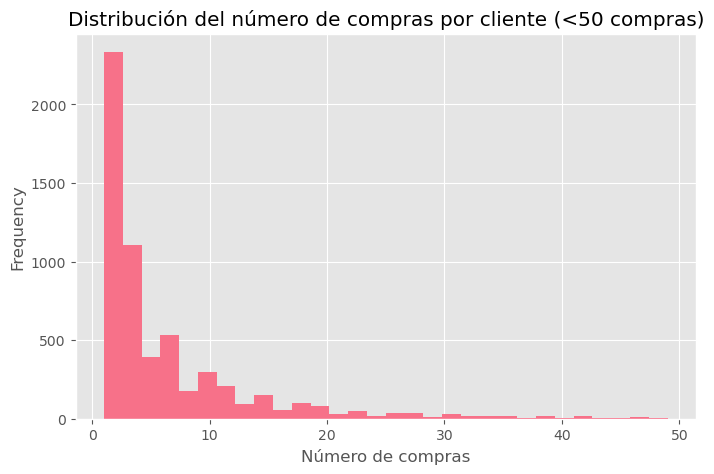

In [13]:
# Número de compras (facturas únicas) por cliente
customer_purchases = df.groupby("customer_id")["invoice"].nunique()

# Resumen estadístico
display(customer_purchases.describe().to_frame("compras_por_cliente"))

# Histograma recortado para mejorar visualización
ax = customer_purchases[customer_purchases < 50].plot(
    kind="hist", bins=30, figsize=(8, 5),
    title="Distribución del número de compras por cliente (<50 compras)"
)
ax.set_xlabel("Número de compras")
plt.show()

La distribución del número de compras por cliente es altamente asimétrica, con una gran concentración de clientes que realizan pocas compras y un grupo reducido que acumula un alto número de transacciones.

Este patrón es característico del retail y refleja la coexistencia de:

- Clientes ocasionales (bajo engagement)
- Clientes recurrentes (alto valor)

**Implicación de negocio:**  
Es fundamental identificar y fidelizar a los clientes recurrentes, ya que generan una parte significativa del valor total del negocio.

---

## ***Distribución de compras normales vs devoluciones***

,n_registros,porcentaje
is_return,,
False,779425,97.69
True,18390,2.31


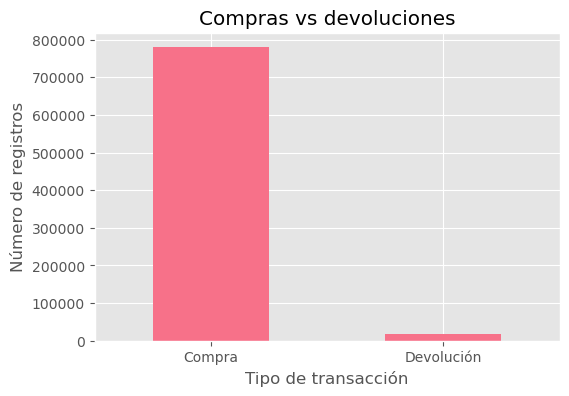

In [17]:
# Distribución de compras normales vs devoluciones
return_counts = df["is_return"].value_counts()
return_pct = (df["is_return"].value_counts(normalize=True) * 100).round(2)

returns_summary = pd.DataFrame({
    "n_registros": return_counts,
    "porcentaje": return_pct
})

display(returns_summary)

ax = return_counts.rename({False: "Compra", True: "Devolución"}).plot(
    kind="bar", figsize=(6, 4), title="Compras vs devoluciones"
)
ax.set_xlabel("Tipo de transacción")
ax.set_ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()

-   Las devoluciones representan aproximadamente un **2–3% del total de transacciones**, lo que indica que la gran mayoría de las operaciones corresponden a compras efectivas.
-   No obstante, su presencia no es despreciable y puede estar asociada a aspectos como errores logísticos, insatisfacción del cliente o características del producto.

---

## ***Distribución deTop 10 productos más frecuentes***

,n_transacciones
stock_code,
85123A,5156
22423,3676
85099B,3380
84879,2709
20725,2686
21212,2582
21232,2122
47566,2120
20727,2089


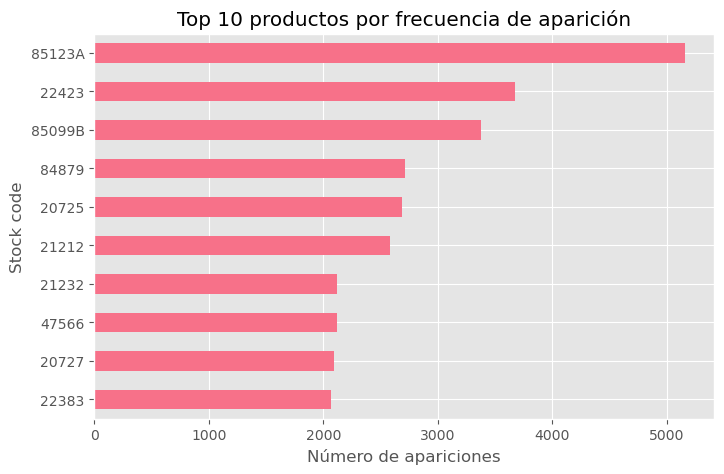

In [18]:
# Top 10 productos más frecuentes por stock_code
top_products = df["stock_code"].value_counts().head(10)

display(top_products.to_frame("n_transacciones"))

ax = top_products.sort_values().plot(
    kind="barh", figsize=(8, 5), title="Top 10 productos por frecuencia de aparición"
)
ax.set_xlabel("Número de apariciones")
ax.set_ylabel("Stock code")
plt.show()

-   Un número reducido de productos concentra una gran parte de las transacciones, lo que refleja una estructura de ventas tipo **“long tail”**, donde unos pocos artículos tienen una alta rotación mientras que la mayoría presentan baja frecuencia.
-   Esto sugiere la existencia de productos clave o “best-sellers” que impulsan gran parte del negocio.

---

## ***Distribución temporal de transacciones por mes***

C:\Users\User\AppData\Local\Temp\ipykernel_25732\3711344850.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("invoice_date").resample("M").size().plot(figsize=(10,4))


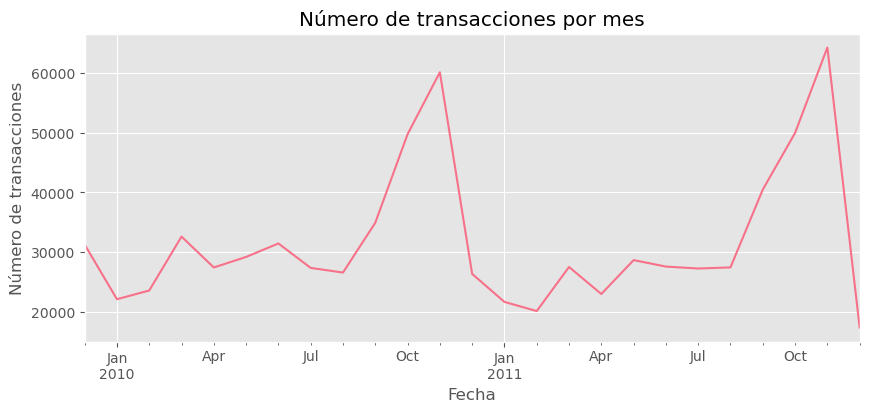

In [19]:
# Número de transacciones por mes
df.set_index("invoice_date").resample("M").size().plot(figsize=(10,4))

plt.title("Número de transacciones por mes")
plt.xlabel("Fecha")
plt.ylabel("Número de transacciones")
plt.show()

-   El volumen de transacciones muestra una clara **estacionalidad**, con picos pronunciados en los meses de **octubre a diciembre**, coincidiendo con la campaña navideña.
-   Este patrón se repite en los distintos años, lo que sugiere que el comportamiento de compra está fuertemente influenciado por eventos comerciales y periodos de alta demanda.

Además, tras estos picos se observa una caída significativa en enero, lo que indica un efecto post-campaña típico del retail.

---


## ***Distribución de ticket por factura***

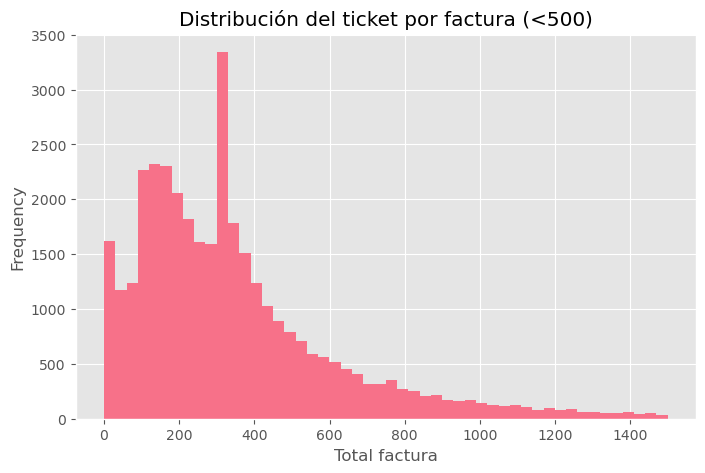

In [30]:
invoice_total = df.groupby("invoice")["total_price"].sum()

invoice_total[(invoice_total > 0)&(invoice_total <1500)].plot(kind="hist", bins=50, figsize=(8,5))
plt.title("Distribución del ticket por factura (<500)")
plt.xlabel("Total factura")
plt.show()

-   La distribución del importe total por factura muestra una clara asimetría hacia la derecha, con una gran concentración de compras de bajo importe y una cola larga de transacciones de alto valor.
-   Esto indica que la mayoría de las compras son pequeñas o moderadas, mientras que existe un número reducido de pedidos con importes elevados que pueden tener un impacto significativo en la facturación total.
-   Este comportamiento es típico en entornos retail y sugiere la coexistencia de clientes ocasionales con compras pequeñas y clientes de mayor valor que realizan compras más grandes.

---

## ***Distribución de la Relación entre cantidad y precio***

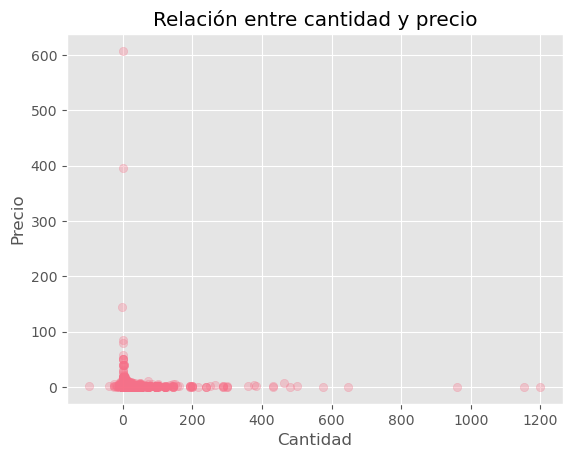

In [33]:
sample_df = df.sample(5000)

plt.scatter(sample_df["quantity"], sample_df["price"], alpha=0.3)
plt.title("Relación entre cantidad y precio")
plt.xlabel("Cantidad")
plt.ylabel("Precio")
plt.show()

-   El análisis de la relación entre cantidad y precio no muestra una correlación clara entre ambas variables. La mayoría de los productos se concentran en precios bajos independientemente de la cantidad adquirida.
-   Se observan algunos valores atípicos, tanto en cantidades elevadas como en precios altos, lo que sugiere la presencia de compras poco frecuentes o comportamientos anómalos.
-   En general, el precio de los productos no parece depender directamente del volumen comprado, lo que indica que no hay una estrategia clara de descuentos por volumen en los datos observados.

---

## ***Distribución de la Frecuencia vs Gasto por cliente***

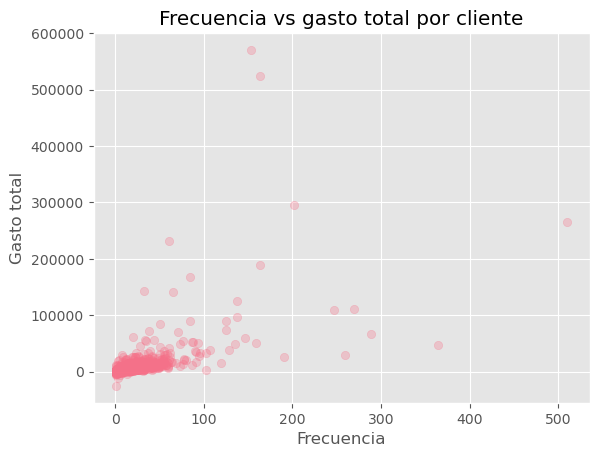

In [34]:
customer_data = df.groupby("customer_id").agg({
    "invoice": "nunique",
    "total_price": "sum"
}).rename(columns={"invoice": "frequency", "total_price": "monetary"})

plt.scatter(customer_data["frequency"], customer_data["monetary"], alpha=0.3)
plt.title("Frecuencia vs gasto total por cliente")
plt.xlabel("Frecuencia")
plt.ylabel("Gasto total")
plt.show()

Se observa una relación positiva entre la frecuencia de compra y el gasto total por cliente, lo que indica que los clientes más activos tienden a generar mayor valor para el negocio.

Sin embargo, la dispersión de los datos muestra que no todos los clientes frecuentes son necesariamente los que más gastan, lo que sugiere la existencia de distintos perfiles de cliente:

- Clientes frecuentes con compras pequeñas
- Clientes menos frecuentes pero con tickets elevados

Este patrón refuerza la importancia de segmentar a los clientes en función de múltiples variables (frecuencia, gasto, recencia) y no únicamente por una dimensión.

---

## ***Ratio de devoluciones por país***

C:\Users\User\AppData\Local\Temp\ipykernel_25732\2447500576.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  returns_by_country = df.groupby("country")["is_return"].mean().sort_values(ascending=False).head(10)


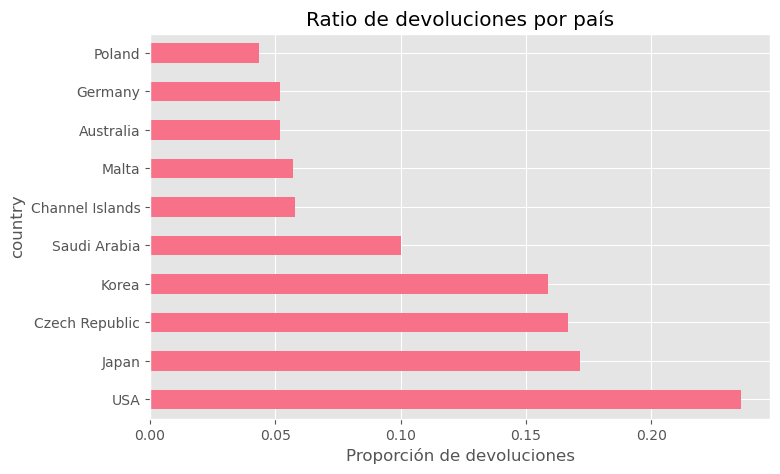

In [35]:
returns_by_country = df.groupby("country")["is_return"].mean().sort_values(ascending=False).head(10)

returns_by_country.plot(kind="barh", figsize=(8,5))
plt.title("Ratio de devoluciones por país")
plt.xlabel("Proporción de devoluciones")
plt.show()

El análisis del ratio de devoluciones por país muestra diferencias significativas entre mercados, con algunos países presentando una proporción mayor de devoluciones que otros.

Esto puede estar relacionado con factores como:
- Diferencias en la satisfacción del cliente
- Problemas logísticos o de envío
- Políticas de devolución específicas por región

Aunque el volumen total de devoluciones es bajo, estas diferencias pueden ser relevantes para optimizar operaciones y mejorar la experiencia del cliente en determinados mercados.

---

## ***Matriz de correlación entre variables numéricas***

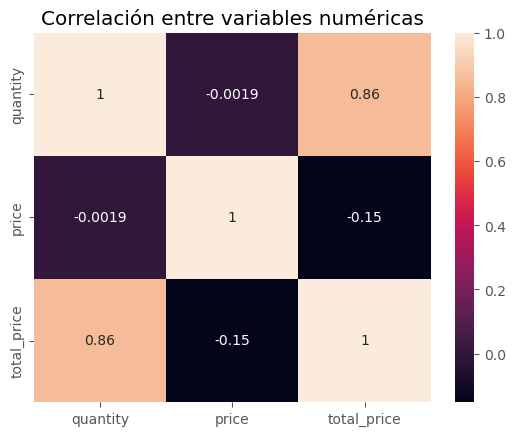

In [37]:
corr = df[["quantity", "price", "total_price"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlación entre variables numéricas")
plt.show()

-   La matriz de correlación muestra una relación fuerte y positiva entre la cantidad y el total de la factura, lo cual es esperable dado que el total depende directamente de la cantidad adquirida.
-   Por otro lado, el precio presenta una correlación débil o incluso ligeramente negativa con el total, lo que indica que los productos más caros no necesariamente generan mayores importes totales en las transacciones.

Esto sugiere que el volumen de productos comprados tiene un mayor impacto en el valor total de la compra que el precio unitario de los mismos.

---

# ***Conclusión del análisis exploratorio avanzado***

El análisis exploratorio revela patrones claros en el comportamiento de compra de los clientes:

- Predominan las compras de bajo importe, con una minoría de transacciones de alto valor.
- No existe una relación directa entre precio y cantidad, lo que sugiere una estructura de precios independiente del volumen.
- Los clientes más frecuentes tienden a generar mayor valor, aunque existen distintos perfiles de consumo.
- Las devoluciones son poco frecuentes, pero presentan variabilidad entre países.
- El valor total de las transacciones está principalmente impulsado por la cantidad de productos adquiridos.
- Fuerte estacionalidad en periodos clave (especialmente campaña navideña)
- Alta concentración geográfica en un mercado principal
- Distribución desigual de clientes, donde una minoría genera gran parte del valor
- Bajo pero relevante nivel de devoluciones

Estos hallazgos refuerzan la importancia de variables como la frecuencia, la recencia y el gasto total, que posteriormente se han utilizado en el modelo de machine learning.